<a href="https://colab.research.google.com/github/abimouloud/TokenMobileViT/blob/main/Token_learner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning to tokenize in Vision Transformers

**Authors:** [Aritra Roy Gosthipaty](https://twitter.com/ariG23498), [Sayak Paul](https://twitter.com/RisingSayak) (equal contribution)<br>
**Date created:** 2021/12/10<br>
**Last modified:** 2026/08/022 by: ABIMOULOUD mouhamed laid<br>
Cite this article: TokenMobileViT: A Lightweight Hybrid Vision
Transformer with Learnable Token Compression
for Lung and Colon Classification

## Introduction

Vision Transformers ([Dosovitskiy et al.](https://arxiv.org/abs/2010.11929)) and many
other Transformer-based architectures ([Liu et al.](https://arxiv.org/abs/2103.14030),
[Yuan et al.](https://arxiv.org/abs/2101.11986), etc.) have shown strong results in
image recognition. The following provides a brief overview of the components involved in the
Vision Transformer architecture for image classification:

* Extract small patches from input images.
* Linearly project those patches.
* Add positional embeddings to these linear projections.
* Run these projections through a series of Transformer ([Vaswani et al.](https://arxiv.org/abs/1706.03762))
blocks.
* Finally, take the representation from the final Transformer block and add a
classification head.

If we take 224x224 images and extract 16x16 patches, we get a total of 196 patches (also
called tokens) for each image. The number of patches increases as we increase the
resolution, leading to higher memory footprint. Could we use a reduced
number of patches without having to compromise performance?
Ryoo et al. investigate this question in
[TokenLearner: Adaptive Space-Time Tokenization for Videos](https://openreview.net/forum?id=z-l1kpDXs88).
They introduce a novel module called **TokenLearner** that can help reduce the number
of patches used by a Vision Transformer (ViT) in an adaptive manner. With TokenLearner
incorporated in the standard ViT architecture, they are able to reduce the amount of
compute (measured in FLOPS) used by the model.

In this example, we implement the TokenLearner module and demonstrate its
performance with a mini ViT and the CIFAR-10 dataset. We make use of the following
references:

* [Official TokenLearner code](https://github.com/google-research/scenic/blob/main/scenic/projects/token_learner/model.py)
* [Image Classification with ViTs on keras.io](https://keras.io/examples/vision/image_classification_with_vision_transformer/)
* [TokenLearner slides from NeurIPS 2021](https://nips.cc/media/neurips-2021/Slides/26578.pdf)

In [ ]:
!pip install -U tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 13.7 MB/s eta 0:00:00


## Imports

In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa

from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

import math

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa
import tensorflow as tf

from keras.applications import imagenet_utils
from tensorflow.keras import layers
from tensorflow import keras

import tensorflow_datasets as tfds
import tensorflow_addons as tfa
from tensorflow.keras import layers
from tensorflow import keras
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import tensorflow_addons as tfa
import tensorflow as tf
import numpy as np
import json
import math
import os

import cv2
from PIL import Image
import numpy as np
from keras import layers
from keras.applications import ResNet50,MobileNet, DenseNet201, InceptionV3, NASNetLarge, InceptionResNetV2, NASNetMobile
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
import scipy
from tqdm import tqdm
import tensorflow as tf
from keras import backend as K
import gc
from functools import partial
from sklearn import metrics
from collections import Counter
import json
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

tfds.disable_progress_bar()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Transfer 'jpg' images to an array IMG
def Dataset_loader(DIR, RESIZE, sigmaX=10):
    IMG = []
    read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))
    for IMAGE_NAME in tqdm(os.listdir(DIR)):
        PATH = os.path.join(DIR,IMAGE_NAME)
        _, ftype = os.path.splitext(PATH)
        if ftype == ".png":
            img = read(PATH)

            img = cv2.resize(img, (RESIZE,RESIZE))

            IMG.append(np.array(img))
    return IMG



benign_train = np.array(Dataset_loader('your path',224))
malign_train = np.array(Dataset_loader('your path',224))
benign_test = np.array(Dataset_loader('/your path',224))
malign_test = np.array(Dataset_loader('your path',224))

 76%|███████▌  | 211/278 [00:14<00:02, 32.65it/s]

In [ ]:
# Skin Cancer: Malignant vs. Benign
# Create labels
benign_train_label = np.zeros(len(benign_train))
malign_train_label = np.ones(len(malign_train))
benign_test_label = np.zeros(len(benign_test))
malign_test_label = np.ones(len(malign_test))

# Merge data
X_train = np.concatenate((benign_train, malign_train), axis = 0)
Y_train = np.concatenate((benign_train_label, malign_train_label), axis = 0)
X_test = np.concatenate((benign_test, malign_test), axis = 0)
Y_test = np.concatenate((benign_test_label, malign_test_label), axis = 0)

# Shuffle train data
s = np.arange(X_train.shape[0])
np.random.shuffle(s)
X_train = X_train[s]
Y_train = Y_train[s]

# Shuffle test data
s = np.arange(X_test.shape[0])
np.random.shuffle(s)
X_test = X_test[s]
Y_test = Y_test[s]

# To categorical
Y_train = to_categorical(Y_train, num_classes= 2)
Y_test = to_categorical(Y_test, num_classes= 2)

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    X_train, Y_train,
    test_size=0.2,
    random_state=11
)

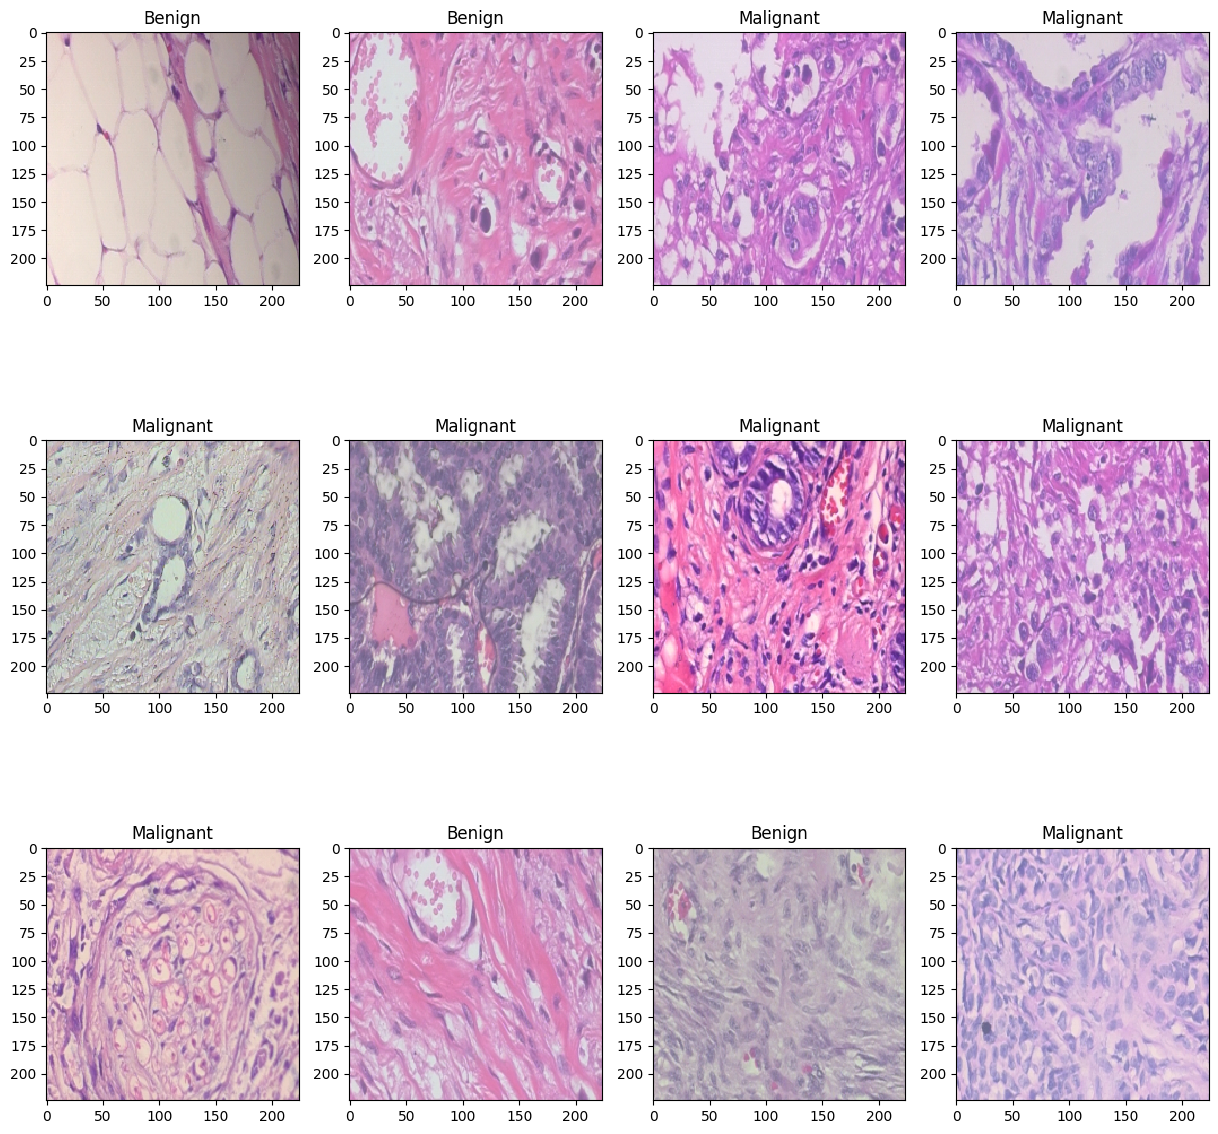

In [ ]:
# # Display first 15 images of moles, and how they are classified
w=60
h=40
fig=plt.figure(figsize=(15, 15))
columns = 4
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if np.argmax(Y_train[i]) == 0:
        ax.title.set_text('Benign')
    else:
        ax.title.set_text('Malignant')
    plt.imshow(x_train[i], interpolation='nearest')
plt.show()

## Hyperparameters

Please feel free to change the hyperparameters and check your results. The best way to
develop intuition about the architecture is to experiment with it.

In [ ]:
# DATA
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE
INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 2

# OPTIMIZER
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# TRAINING
EPOCHS = 100

# AUGMENTATION
IMAGE_SIZE = 224  # We will resize input images to this size.
PATCH_SIZE = 14 # Size of the patches to be extracted from the input images.
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# ViT ARCHITECTURE
LAYER_NORM_EPS = 1e-6
PROJECTION_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 4
MLP_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]

# TOKENLEARNER
NUM_TOKENS = 4

## Load and prepare the CIFAR-10 dataset

## Data augmentation

The augmentation pipeline consists of:

- Rescaling
- Resizing
- Random cropping (fixed-sized or random sized)
- Random horizontal flipping

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(
            height_factor=0.2, width_factor=0.2
        ),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
data_augmentation.layers[0].adapt(x_train)


Note that image data augmentation layers do not apply data transformations at inference time.
This means that when these layers are called with `training=False` they behave differently. Refer
[to the documentation](https://keras.io/api/layers/preprocessing_layers/image_augmentation/) for more
details.

## Positional embedding module

A [Transformer](https://arxiv.org/abs/1706.03762) architecture consists of **multi-head
self attention** layers and **fully-connected feed forward** networks (MLP) as the main
components. Both these components are _permutation invariant_: they're not aware of
feature order.

To overcome this problem we inject tokens with positional information. The
`position_embedding` function adds this positional information to the linearly projected
tokens.

In [ ]:

def position_embedding(
    projected_patches, num_patches=NUM_PATCHES, projection_dim=PROJECTION_DIM
):
    # Build the positions.
    positions = tf.range(start=0, limit=num_patches, delta=1)

    # Encode the positions with an Embedding layer.
    encoded_positions = layers.Embedding(
        input_dim=num_patches, output_dim=projection_dim
    )(positions)

    # Add encoded positions to the projected patches.
    return projected_patches + encoded_positions


## MLP block for Transformer

This serves as the Fully Connected Feed Forward block for our Transformer.

In [ ]:

def mlp(x, dropout_rate, hidden_units):
    # Iterate over the hidden units and
    # add Dense => Dropout.
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


## TokenLearner module

The following figure presents a pictorial overview of the module
([source](https://ai.googleblog.com/2021/12/improving-vision-transformer-efficiency.html)).

![TokenLearner module GIF](https://blogger.googleusercontent.com/img/a/AVvXsEiylT3_nmd9-tzTnz3g3Vb4eTn-L5sOwtGJOad6t2we7FsjXSpbLDpuPrlInAhtE5hGCA_PfYTJtrIOKfLYLYGcYXVh1Ksfh_C1ZC-C8gw6GKtvrQesKoMrEA_LU_Gd5srl5-3iZDgJc1iyCELoXtfuIXKJ2ADDHOBaUjhU8lXTVdr2E7bCVaFgVHHkmA=w640-h208)

The TokenLearner module takes as input an image-shaped tensor. It then passes it through
multiple single-channel convolutional layers extracting different spatial attention maps
focusing on different parts of the input. These attention maps are then element-wise
multiplied to the input and result is aggregated with pooling. This pooled output can be
trated as a summary of the input and has much lesser number of patches (8, for example)
than the original one (196, for example).

Using multiple convolution layers helps with expressivity. Imposing a form of spatial
attention helps retain relevant information from the inputs. Both of these components are
crucial to make TokenLearner work, especially when we are significantly reducing the number of patches.

In [ ]:

def token_learner(inputs, number_of_tokens=NUM_TOKENS):
    # Layer normalize the inputs.
    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(inputs)  # (B, H, W, C)

    # Applying Conv2D => Reshape => Permute
    # The reshape and permute is done to help with the next steps of
    # multiplication and Global Average Pooling.
    attention_maps = keras.Sequential(
        [
            # 3 layers of conv with gelu activation as suggested
            # in the paper.
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            # This conv layer will generate the attention maps
            layers.Conv2D(
                filters=number_of_tokens,
                kernel_size=(3, 3),
                activation="sigmoid",  # Note sigmoid for [0, 1] output
                padding="same",
                use_bias=False,
            ),
            # Reshape and Permute
            layers.Reshape((-1, number_of_tokens)),  # (B, H*W, num_of_tokens)
            layers.Permute((2, 1)),
        ]
    )(
        x
    )  # (B, num_of_tokens, H*W)

    # Reshape the input to align it with the output of the conv block.
    num_filters = inputs.shape[-1]
    inputs = layers.Reshape((1, -1, num_filters))(inputs)  # inputs == (B, 1, H*W, C)

    # Element-Wise multiplication of the attention maps and the inputs
    attended_inputs = (
        attention_maps[..., tf.newaxis] * inputs
    )  # (B, num_tokens, H*W, C)

    # Global average pooling the element wise multiplication result.
    outputs = tf.reduce_mean(attended_inputs, axis=2)  # (B, num_tokens, C)
    return outputs


## Transformer block

In [ ]:

def transformer(encoded_patches):
    # Layer normalization 1.
    x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(encoded_patches)

    # Multi Head Self Attention layer 1.
    attention_output = layers.MultiHeadAttention(
        num_heads=NUM_HEADS, key_dim=PROJECTION_DIM, dropout=0.1
    )(x1, x1)

    # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])

    # Layer normalization 2.
    x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

    # MLP layer 1.
    x4 = mlp(x3, hidden_units=MLP_UNITS, dropout_rate=0.1)

    # Skip connection 2.
    encoded_patches = layers.Add()([x4, x2])
    return encoded_patches


## ViT model with the TokenLearner module

In [ ]:

def create_vit_classifier(use_token_learner=True, token_learner_units=NUM_TOKENS):
    inputs = layers.Input(shape=INPUT_SHAPE)  # (B, H, W, C)

    # Augment data.
    augmented = data_augmentation(inputs)

    # Create patches and project the pathces.
    projected_patches = layers.Conv2D(
        filters=PROJECTION_DIM,
        kernel_size=(PATCH_SIZE, PATCH_SIZE),
        strides=(PATCH_SIZE, PATCH_SIZE),
        padding="VALID",
    )(augmented)
    _, h, w, c = projected_patches.shape
    projected_patches = layers.Reshape((h * w, c))(
        projected_patches
    )  # (B, number_patches, projection_dim)

    # Add positional embeddings to the projected patches.
    encoded_patches = position_embedding(
        projected_patches
    )  # (B, number_patches, projection_dim)
    encoded_patches = layers.Dropout(0.1)(encoded_patches)

    # Iterate over the number of layers and stack up blocks of
    # Transformer.
    for i in range(NUM_LAYERS):
        # Add a Transformer block.
        encoded_patches = transformer(encoded_patches)

        # Add TokenLearner layer in the middle of the
        # architecture. The paper suggests that anywhere
        # between 1/2 or 3/4 will work well.
        if use_token_learner and i == NUM_LAYERS // 2:
            _, hh, c = encoded_patches.shape
            h = int(math.sqrt(hh))
            encoded_patches = layers.Reshape((h, h, c))(
                encoded_patches
            )  # (B, h, h, projection_dim)
            encoded_patches = token_learner(
                encoded_patches, token_learner_units
            )  # (B, num_tokens, c)

    # Layer normalization and Global average pooling.
    representation = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(encoded_patches)
    representation = layers.GlobalAvgPool1D()(representation)

    # Classify outputs.
    outputs = layers.Dense(NUM_CLASSES, activation="sigmoid")(representation)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


## Training utility

## Train and evaluate a ViT with TokenLearner

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from tensorflow import keras
import time


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, cohen_kappa_score, matthews_corrcoef
from tensorflow import keras
import time

def run_experiment(model, X_train, Y_train, X_test, Y_test, num_epochs, batch_size, num_classes):
    optimizer = 'Adam'

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    checkpoint_filepath = "/content/drive/MyDrive/SAVE"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    start_time = time.time()  # Record the start time
    history = model.fit(
        x=X_train,
        y=Y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )
    end_time = time.time()  # Record the end time

    model.load_weights(checkpoint_filepath)
    _, accuracy = model.evaluate(X_test, Y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    # Calculate total training time
    total_training_time = end_time - start_time

    # Calculate average training time per epoch
    avg_training_time_per_epoch = total_training_time / num_epochs

    # Print the training times
    print("Total Training Time (s):", total_training_time)
    print("Average Training Time per Epoch (s):", avg_training_time_per_epoch)

    # Get predicted probabilities for test data
    Y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

    # Calculate Precision, Sensitivity, and Specificity
    true_positives = np.diag(cm)
    false_positives = np.sum(cm, axis=0) - true_positives
    false_negatives = np.sum(cm, axis=1) - true_positives
    true_negatives = np.sum(cm) - (true_positives + false_positives + false_negatives)

    precision = true_positives / (true_positives + false_positives)
    sensitivity = true_positives / (true_positives + false_negatives)
    specificity = true_negatives / (true_negatives + false_positives)

    # Calculate MCC
    mcc = matthews_corrcoef(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

    # Calculate Kappa
    kappa = cohen_kappa_score(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))

    # Calculate G-mean
    g_mean = np.sqrt(sensitivity * specificity)

    # Calculate AUC
    y_test_labels = np.argmax(Y_test, axis=1)
    y_pred_probabilities = Y_pred[:, 1]  # Assuming binary classification, adjust accordingly
    auc = roc_auc_score(y_test_labels, y_pred_probabilities)

    # Calculate AUC for class 0
    fpr_0, tpr_0, _ = roc_curve(Y_test[:, 0], Y_pred[:, 0])
    auc_0 = roc_auc_score(Y_test[:, 0], Y_pred[:, 0])

    # Calculate AUC for class 1
    fpr_1, tpr_1, _ = roc_curve(Y_test[:, 1], Y_pred[:, 1])
    auc_1 = roc_auc_score(Y_test[:, 1], Y_pred[:, 1])

    # Plot confusion matrix
    classes = range(num_classes)  # Replace with your actual class labels
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.xticks(ticks=classes, labels=classes)
    plt.yticks(ticks=classes, labels=classes)
    plt.show()

    # Plot ROC curve for both classes
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_0, tpr_0, color='red', label='Class 0 ROC (benign) curve (area = %0.2f)' % auc_0)
    plt.plot(fpr_1, tpr_1, color='green', label='Class 1 ROC (malign) (area = %0.2f)' % auc_1)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # Print Precision, Sensitivity, Specificity, MCC, Kappa, G-mean, and AUC
    print("Precision:", precision)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("MCC:", mcc)
    print("Kappa:", kappa)
    print("G-mean:", g_mean)
    print("AUC (Class 0):", auc_0)
    print("AUC (Class 1):", auc_1)

    # Print Mean Precision, Sensitivity, Specificity, MCC, Kappa, G-mean, and AUC
    print("Mean Precision:", np.mean(precision))
    print("Mean Sensitivity:", np.mean(sensitivity))
    print("Mean Specificity:", np.mean(specificity))
    print("Mean MCC:", mcc)
    print("Mean Kappa:", kappa)
    print("Mean G-mean:", np.mean(g_mean))
    print("AUC:", np.mean(auc))

    print("Mean AUC (Class 0):", np.mean(auc_0))
    print("Mean AUC (Class 1):", np.mean(auc_1))

    return history

# Create your VIT classifier
vit_classifier = create_vit_classifier()  # Define create_vit_classifier() as needed
# Define X_train, Y_train, X_test, Y_test, num_epochs, batch_size, num_classes as needed
history = run_experiment(vit_classifier, X_train, Y_train, X_test, Y_test, num_epochs, batch_size, num_classes)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from tensorflow import keras
import time

def run_experiment(model):
    optimizer = 'SGD'

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    checkpoint_filepath = "/content/drive/MyDrive/SAVE"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    start_time = time.time()  # Record the start time
    history = model.fit(
        x=X_train,
        y=Y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )
    end_time = time.time()  # Record the end time

    model.load_weights(checkpoint_filepath)
    _, accuracy = model.evaluate(X_test, Y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    # Calculate total training time
    total_training_time = end_time - start_time

    # Calculate average training time per epoch
    avg_training_time_per_epoch = total_training_time / EPOCHS

    # Print the training times
    print("Total Training Time (s):", total_training_time)
    print("Average Training Time per Epoch (s):", avg_training_time_per_epoch)

    # Get predicted probabilities for test data
    Y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(np.argmax(Y_test, axis=1), np.argmax(Y_pred, axis=1))
    # Calculate Precision, Sensitivity, and Specificity
    true_positives = np.diag(cm)
    false_positives = np.sum(cm, axis=0) - true_positives
    false_negatives = np.sum(cm, axis=1) - true_positives
    true_negatives = np.sum(cm) - (true_positives + false_positives + false_negatives)

    precision = true_positives / (true_positives + false_positives)
    sensitivity = true_positives / (true_positives + false_negatives)
    specificity = true_negatives / (true_negatives + false_positives)


    # Calculate AUC
    y_test_labels = np.argmax(Y_test, axis=1)
    y_pred_probabilities = Y_pred[:, 1]  # Assuming binary classification, adjust accordingly
    auc = roc_auc_score(y_test_labels, y_pred_probabilities)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

    # Calculate AUC for class 0
    fpr_0, tpr_0, _ = roc_curve(Y_test[:, 0], Y_pred[:, 0])
    auc_0 = roc_auc_score(Y_test[:, 0], Y_pred[:, 0])

    # Calculate AUC for class 1
    fpr_1, tpr_1, _ = roc_curve(Y_test[:, 1], Y_pred[:, 1])
    auc_1 = roc_auc_score(Y_test[:, 1], Y_pred[:, 1])

    # Plot confusion matrix
    classes = range(NUM_CLASSES)  # Replace with your actual class labels
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 35})
    plt.title("Confusion Matrix", size=35)
    plt.xlabel("Predicted Labels", size=35)
    plt.ylabel("True Labels")
    plt.xticks(ticks=classes, labels=classes)
    plt.yticks(ticks=classes, labels=classes)
    plt.show()

    # Plot ROC curve for both classes
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_0, tpr_0, color='red', label='Class 0 ROC (benign)' % auc_0)
    plt.plot(fpr_1, tpr_1, color='green', label='Class 1 ROC (malign) ' % auc_1)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right",prop={'size': 10})
    plt.show()

    # Print Precision, Sensitivity, Specificity, and AUC
    print("Precision:", precision)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("AUC (Class 0):", auc_0)
    print("AUC (Class 1):", auc_1)

    # Print Mean Precision, Sensitivity, Specificity, and AUC
    print("Mean Precision:", np.mean(precision))
    print("Mean Sensitivity:", np.mean(sensitivity))
    print("Mean Specificity:", np.mean(specificity))
    print("AUC:", np.mean(auc))
    print("F1 Score:", np.mean(f1))

    print("Mean AUC (Class 0):", np.mean(auc_0))
    print("Mean AUC (Class 1):", np.mean(auc_1))



    return history

vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)


